<a href="https://colab.research.google.com/github/pantera-rosa/vuln-management-capstone/blob/eric_branch/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [4]:
import os, time, math, json
from typing import List
from datetime import datetime, timedelta

import pandas as pd
import matplotlib.pyplot as plt
import requests
import subprocess

In [5]:
def read_json(curl_command):
  try:
    # Execute the curl command using subprocess
    result = subprocess.run(curl_command, shell=True, capture_output=True, text=True, check=True)
    response_raw = result.stdout
    response_json = json.loads(response_raw)
    return response_json
  except subprocess.CalledProcessError as e:
    print(f"Curl command failed: {e}")
    print(f"Stderr: {e.stderr}")
    return None
  except json.JSONDecodeError:
    print("Raw response (not JSON or invalid JSON):")
    print(response_raw)
    return None

## CVE Records

In [ ]:
# Construct the URL for the CVE data in the cvelistv5 GitHub repository
cve_id = "CVE-2019-1010218"
year = cve_id.split('-')[1] # Extract the year from the CVE ID
id_prefix = cve_id.split('-')[2][:-3] # Extract the all but the last 3 digits of the id from the CVE ID

In [ ]:
# The structure of the cvelistv5 repo is cves/{year}/{id_prefix}xxx/{cve_id}.json
cvelist_url = f"https://raw.githubusercontent.com/CVEProject/cvelistV5/refs/heads/main/cves/{year}/{id_prefix}xxx/{cve_id}.json"

# Create a curl command to fetch the data
cvelist_curl_command = f"curl {cvelist_url}"

# Use the read_json function to fetch and parse the data
cvelist_data_json = read_json(cvelist_curl_command)

# Display the fetched data
if cvelist_data_json:
    display(cvelist_data_json)
else:
    print(f"Could not fetch or parse data for {cve_id} from cvelistv5.")

{'containers': {'cna': {'affected': [{'product': 'Latest Cherokee Web server',
     'vendor': 'Cherokee Webserver',
     'versions': [{'status': 'affected',
       'version': "Upto Version 1.2.103 (Current stable) [fixed: There's no fix yet]"}]}],
   'descriptions': [{'lang': 'en',
     'value': "Cherokee Webserver Latest Cherokee Web server Upto Version 1.2.103 (Current stable) is affected by: Buffer Overflow - CWE-120. The impact is: Crash. The component is: Main cherokee command. The attack vector is: Overwrite argv[0] to an insane length with execl. The fixed version is: There's no fix yet."}],
   'problemTypes': [{'descriptions': [{'cweId': 'CWE-120',
       'description': 'Buffer Overflow - CWE-120',
       'lang': 'en',
       'type': 'CWE'}]}],
   'providerMetadata': {'dateUpdated': '2019-07-22T17:30:25',
    'orgId': '7556d962-6fb7-411e-85fa-6cd62f095ba8',
    'shortName': 'dwf'},
   'references': [{'tags': ['x_refsource_MISC'],
     'url': 'https://i.imgur.com/PWCCyir.png'}],

## NVD Data Feeds

In [ ]:
nvd_curl_command = """
curl https://services.nvd.nist.gov/rest/json/cves/2.0?cveId=CVE-2019-1010218
"""

In [ ]:
nvd_data_json = read_json(nvd_curl_command)
nvd_data_json

{'resultsPerPage': 1,
 'startIndex': 0,
 'totalResults': 1,
 'format': 'NVD_CVE',
 'version': '2.0',
 'timestamp': '2025-09-17T05:40:10.074',
 'vulnerabilities': [{'cve': {'id': 'CVE-2019-1010218',
    'sourceIdentifier': 'josh@bress.net',
    'published': '2019-07-22T18:15:10.917',
    'lastModified': '2024-11-21T04:18:03.857',
    'vulnStatus': 'Modified',
    'cveTags': [],
    'descriptions': [{'lang': 'en',
      'value': "Cherokee Webserver Latest Cherokee Web server Upto Version 1.2.103 (Current stable) is affected by: Buffer Overflow - CWE-120. The impact is: Crash. The component is: Main cherokee command. The attack vector is: Overwrite argv[0] to an insane length with execl. The fixed version is: There's no fix yet."},
     {'lang': 'es',
      'value': 'El servidor web de Cherokee más reciente de Cherokee Webserver Hasta Versión 1.2.103 (estable actual) está afectado por: Desbordamiento de Búfer - CWE-120. El impacto es: Bloqueo. El componente es: Comando cherokee principal.

## EPSS Data

In [7]:
epss_curl_command = """
curl https://api.first.org/data/v1/epss?cve=CVE-2019-1010218
"""

In [8]:
epss_data_json = read_json(epss_curl_command)
epss_data_json

{'status': 'OK',
 'status-code': 200,
 'version': '1.0',
 'access': 'public',
 'total': 1,
 'offset': 0,
 'limit': 100,
 'data': [{'cve': 'CVE-2019-1010218',
   'epss': '0.006240000',
   'percentile': '0.692750000',
   'date': '2025-09-18'}]}

In [9]:
# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# EPSS API
BASE_URL = "https://api.first.org/data/v1/epss"

# Output folder (Colab VM)
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

In [10]:
def _epss_payload_to_df(payload: dict) -> pd.DataFrame:
    """Normalize FIRST.org EPSS payload to a tidy DataFrame."""
    data = payload.get("data", [])
    if not data:
        return pd.DataFrame(columns=["cve", "epss", "percentile", "date"])
    df = pd.DataFrame(data)
    # Coerce numeric + datetime
    for col in ["epss", "percentile"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=False)
    # Order
    cols = [c for c in ["cve", "epss", "percentile", "date"] if c in df.columns]
    df = df[cols].sort_values(["date", "epss"], ascending=[True, False]).reset_index(drop=True)
    return df

In [11]:
def fetch_epss_by_cves(cves: List[str], limit: int = 2000, pause_s: float = 0.3, retries: int = 3) -> pd.DataFrame:
    """Fetch EPSS for a list of CVEs. The API accepts comma-separated values; chunk to keep URLs reasonable."""
    if not cves:
        return pd.DataFrame(columns=["cve", "epss", "percentile", "date"])

    dfs = []
    chunk_size = 150
    for i in range(0, len(cves), chunk_size):
        chunk = cves[i:i+chunk_size]
        params = {"cve": ",".join(chunk), "limit": limit}

        # simple retry loop
        attempt = 0
        while True:
            try:
                resp = requests.get(BASE_URL, params=params, timeout=30)
                resp.raise_for_status()
                payload = resp.json()
                dfs.append(_epss_payload_to_df(payload))
                break
            except Exception as e:
                attempt += 1
                if attempt > retries:
                    print(f"[WARN] Failed chunk {i}:{i+chunk_size} after {retries} retries: {e}")
                    break
                time.sleep(1.0 * attempt)
        time.sleep(pause_s)

    if not dfs:
        return pd.DataFrame(columns=["cve", "epss", "percentile", "date"])
    return pd.concat(dfs, ignore_index=True).drop_duplicates(subset=["cve", "date"])

In [12]:
def fetch_epss_snapshot(date_str: str, limit: int = 10000, pause_s: float = 0.2, retries: int = 3) -> pd.DataFrame:
    """Fetch a full daily EPSS snapshot for a given date (YYYY-MM-DD) handling pagination."""
    offset = 0
    dfs = []

    while True:
        params = {"date": date_str, "limit": limit, "offset": offset}
        attempt = 0
        while True:
            try:
                resp = requests.get(BASE_URL, params=params, timeout=60)
                resp.raise_for_status()
                payload = resp.json()
                break
            except Exception as e:
                attempt += 1
                if attempt > retries:
                    print(f"[WARN] Pagination offset={offset} failed after {retries} retries: {e}")
                    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=["cve","epss","percentile","date"])
                time.sleep(1.0 * attempt)

        df = _epss_payload_to_df(payload)
        if df.empty:
            break
        dfs.append(df)

        total = int(payload.get("total", 0))
        offset += limit
        if offset >= total:
            break
        time.sleep(pause_s)

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=["cve", "epss", "percentile", "date"])

In [13]:
def summarize(df: pd.DataFrame, name: str = "DF"):
    print(f"\n--- {name} ---")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("\n.dtypes:\n", df.dtypes, "\n")
    with pd.option_context("display.max_rows", 200):
        print(df.describe(include="all"))
    print("\nNull counts:\n", df.isna().sum())
    if set(["cve","date"]).issubset(df.columns):
        print("\nDuplicates (by cve, date):", df.duplicated(subset=["cve","date"]).sum())

In [14]:
def plot_hist(df: pd.DataFrame, col: str, title: str):
    if df.empty or col not in df.columns:
        print(f"[INFO] nothing to plot for {col}")
        return
    plt.figure()
    df[col].dropna().hist(bins=50)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

In [15]:
def plot_timeseries(df: pd.DataFrame, cves: List[str]):
    """If multiple dates exist for a CVE, plot EPSS over time."""
    if df.empty or "date" not in df.columns:
        print("[INFO] no date column or empty df for timeseries")
        return
    for c in cves:
        sdf = df[df["cve"] == c].sort_values("date")
        if sdf.empty:
            continue
        plt.figure()
        plt.plot(sdf["date"], sdf["epss"], marker="o")
        plt.title(f"EPSS over time — {c}")
        plt.xlabel("date"); plt.ylabel("epss")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [16]:
from datetime import datetime
import pandas as pd
import time, os

def iso_date_range(start_date_str: str, end_date_str: str):
    """Inclusive ISO date range: ['YYYY-MM-DD', ..., 'YYYY-MM-DD']"""
    start = pd.to_datetime(start_date_str).date()
    end   = pd.to_datetime(end_date_str).date()
    return [d.date().isoformat() if hasattr(d, "date") else d.isoformat()
            for d in pd.date_range(start, end, freq="D")]


In [17]:
# Pick your inclusive date window
START_DATE = "2025-09-01"
END_DATE   = "2025-09-10"

dates = iso_date_range(START_DATE, END_DATE)
len(dates), dates[:3], dates[-3:]


(10,
 ['2025-09-01', '2025-09-02', '2025-09-03'],
 ['2025-09-08', '2025-09-09', '2025-09-10'])

In [18]:
# Cache each day's snapshot to avoid re-downloading if you rerun
combined = []
for d in dates:
    cache_path = os.path.join(DATA_DIR, f"epss_snapshot_{d}.parquet")
    if os.path.exists(cache_path):
        df_d = pd.read_parquet(cache_path)
    else:
        df_d = fetch_epss_snapshot(d)
        if not df_d.empty:
            df_d.to_parquet(cache_path, index=False)
            time.sleep(0.2)  # be polite to the API
    if not df_d.empty:
        df_d["snapshot_date"] = pd.to_datetime(d)
        combined.append(df_d)

df_range = pd.concat(combined, ignore_index=True) if combined else pd.DataFrame()
print("Total rows across range:", len(df_range))
df_range.head()


Total rows across range: 2925439


,cve,epss,percentile,date,snapshot_date
0,CVE-2025-4427,0.91570,0.99669,2025-09-01,2025-09-01
1,CVE-2025-47812,0.90996,0.99633,2025-09-01,2025-09-01
2,CVE-2025-47916,0.89125,0.99523,2025-09-01,2025-09-01
3,CVE-2025-49113,0.88128,0.99469,2025-09-01,2025-09-01
4,CVE-2025-53770,0.88053,0.99463,2025-09-01,2025-09-01


In [ ]:
out_path = os.path.join(DATA_DIR, f"epss_snapshots_{START_DATE}_to_{END_DATE}.parquet")
df_range.to_parquet(out_path, index=False)
print("Saved:", out_path)


Saved: /content/data/epss_snapshots_2025-09-01_to_2025-09-10.parquet


In [19]:
# Basic QA
print("Unique dates:", df_range["snapshot_date"].nunique() if "snapshot_date" in df_range else 0)
print("Unique CVEs :", df_range["cve"].nunique() if "cve" in df_range else 0)

# Example: pivot EPSS by date for a few CVEs
sample_cves = df_range["cve"].dropna().unique()[:8].tolist()
pivot = (df_range[df_range["cve"].isin(sample_cves)]
         .pivot_table(index="snapshot_date", columns="cve", values="epss", aggfunc="max")
         .sort_index())
pivot.head(10)


Unique dates: 10
Unique CVEs : 293293


cve,CVE-2025-4427,CVE-2025-47812,CVE-2025-47916,CVE-2025-48827,CVE-2025-48828,CVE-2025-49113,CVE-2025-49704,CVE-2025-53770
snapshot_date,,,,,,,,
2025-09-01,0.91570,0.90996,0.89125,0.74032,0.69961,0.88128,0.69726,0.88053
2025-09-02,0.91570,0.90996,0.89125,0.74032,0.69961,0.88128,0.69726,0.88053
2025-09-03,0.91570,0.90996,0.89125,0.74032,0.69961,0.88128,0.69726,0.88053
2025-09-04,0.92237,0.90996,0.89125,0.74032,0.69961,0.88128,0.72763,0.87002
2025-09-05,0.92237,0.90996,0.89125,0.74032,0.69961,0.88128,0.67400,0.87002
2025-09-06,0.92237,0.90996,0.89125,0.74032,0.69961,0.85599,0.67400,0.87002
2025-09-07,0.92237,0.90996,0.89125,0.74032,0.69961,0.85599,0.67400,0.87002
2025-09-08,0.92237,0.90996,0.89125,0.74032,0.69961,0.85599,0.67400,0.87002
2025-09-09,0.92237,0.91352,0.89125,0.74032,0.69961,0.85599,0.67400,0.87002


In [21]:
def plot_percentile_distribution(df, col="percentile", title="EPSS Percentile Distribution"):
    s = df[col].dropna()
    if s.empty:
        print("[INFO] No percentile data to plot.")
        return

    # Key cutoffs
    q90, q95, q99 = s.quantile([0.90, 0.95, 0.99])

    plt.figure()
    s.hist(bins=50)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.title(title)

    # Annotate cutoffs
    for label, q in [("90th", q90), ("95th", q95), ("99th", q99)]:
        plt.axvline(q, linestyle="--")
        ymax = plt.gca().get_ylim()[1]
        plt.text(q, ymax * 0.95, f"{label}\n{q:.3f}", rotation=90, va="top")

    plt.show()

# Usage:
#plot_percentile_distribution(df)

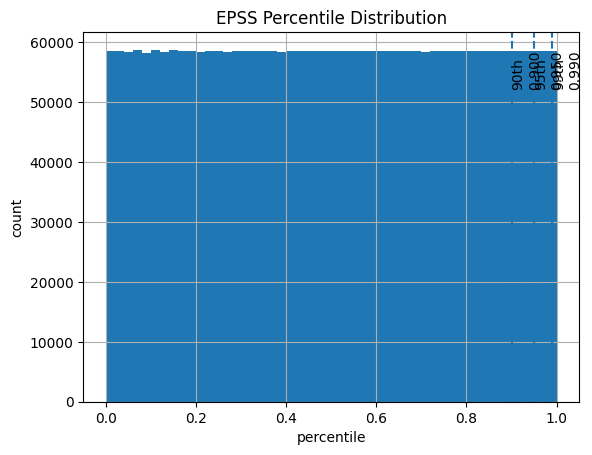

In [25]:
plot_percentile_distribution(df_range)

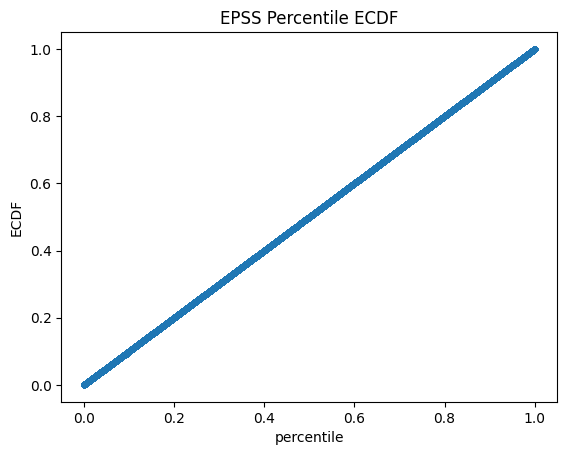

In [26]:
def plot_percentile_ecdf(df, col="percentile", title="EPSS Percentile ECDF"):
    s = df[col].dropna().sort_values()
    if s.empty:
        print("[INFO] No percentile data to plot.")
        return
    y = (range(1, len(s)+1))
    y = [v/len(s) for v in y]

    plt.figure()
    plt.plot(s.values, y, marker=".", linestyle="none")
    plt.xlabel(col)
    plt.ylabel("ECDF")
    plt.title(title)
    plt.show()

# Usage:
plot_percentile_ecdf(df_range)

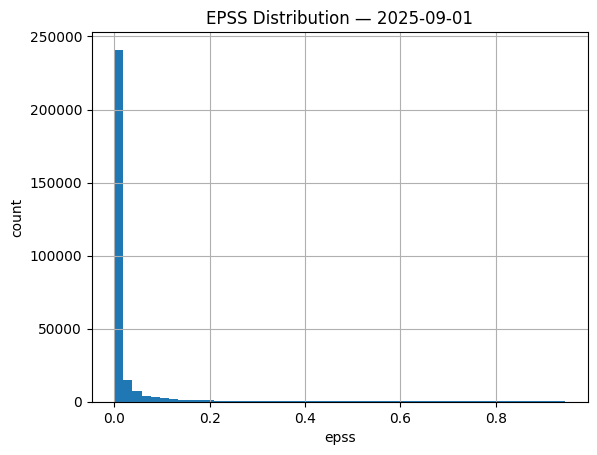

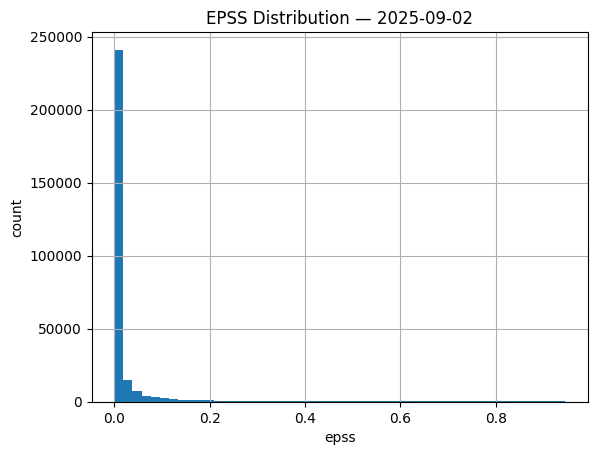

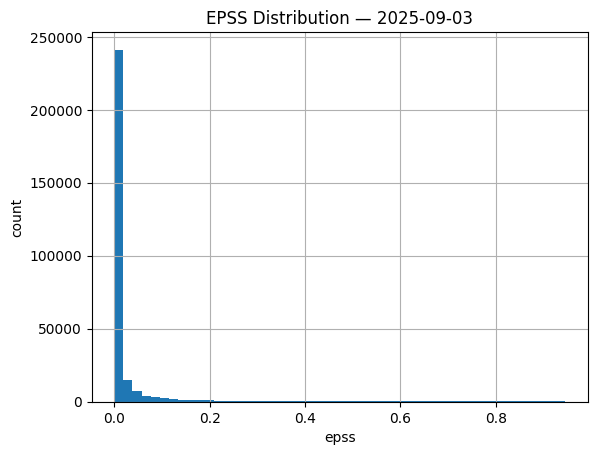

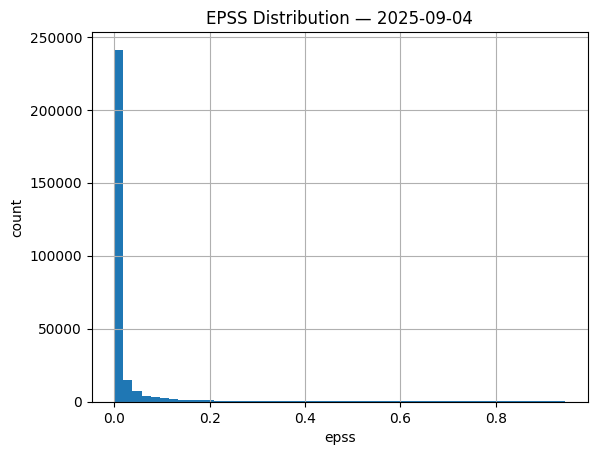

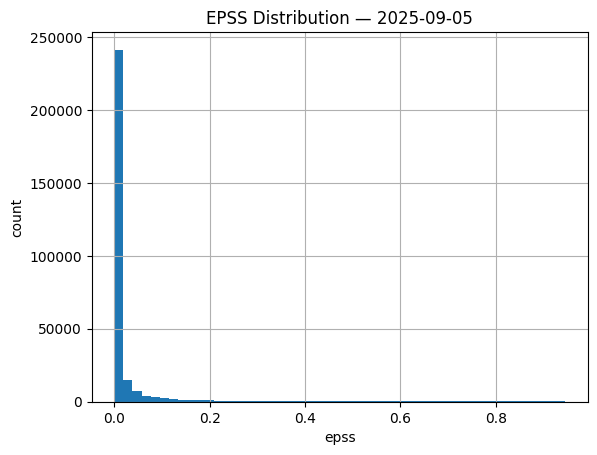

In [ ]:
# Simple per-day EPSS hist loop (avoid too many dates to keep it quick)
for d in dates[:5]:
    sdf = df_range[df_range["snapshot_date"] == pd.to_datetime(d)]
    if sdf.empty:
        continue
    sdf["epss"].dropna().hist(bins=50)
    plt.title(f"EPSS Distribution — {d}")
    plt.xlabel("epss")
    plt.ylabel("count")
    plt.show()


In [ ]:
CVE_LIST = ["CVE-2019-1010218"]

In [ ]:
SNAPSHOT_DATE = (datetime.utcnow() - timedelta(days=7)).date().isoformat()

/tmp/ipython-input-304442989.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  SNAPSHOT_DATE = (datetime.utcnow() - timedelta(days=7)).date().isoformat()


In [ ]:
RUN_MODE = "SNAPSHOT"

In [ ]:
if RUN_MODE.upper() == "CVES":
    df = fetch_epss_by_cves(CVE_LIST)
    mode_name = "cves"
elif RUN_MODE.upper() == "SNAPSHOT":
    df = fetch_epss_snapshot(SNAPSHOT_DATE)
    mode_name = f"snapshot_{SNAPSHOT_DATE}"
else:
    raise ValueError("RUN_MODE must be 'CVES' or 'SNAPSHOT'")

print("Rows fetched:", len(df))
df.head(10)

Rows fetched: 293425


,cve,epss,percentile,date
0,CVE-2025-4427,0.92237,0.99706,2025-09-11
1,CVE-2025-47812,0.91352,0.99646,2025-09-11
2,CVE-2025-47916,0.89125,0.99514,2025-09-11
3,CVE-2025-53770,0.86942,0.99400,2025-09-11
4,CVE-2025-49113,0.85599,0.99331,2025-09-11
5,CVE-2025-48827,0.74032,0.98789,2025-09-11
6,CVE-2025-48828,0.69961,0.98622,2025-09-11
7,CVE-2025-49704,0.67400,0.98521,2025-09-11
8,CVE-2025-4632,0.61238,0.98268,2025-09-11
9,CVE-2025-50201,0.56192,0.98031,2025-09-11


In [ ]:
summarize(df, f"EPSS {mode_name}")


--- EPSS snapshot_2025-09-11 ---
shape: (293425, 4)
columns: ['cve', 'epss', 'percentile', 'date']

.dtypes:
 cve                   object
epss                 float64
percentile           float64
date          datetime64[ns]
dtype: object 

                  cve           epss     percentile                 date
count          293425  293425.000000  293425.000000               293425
unique         293425            NaN            NaN                  NaN
top     CVE-1999-1170            NaN            NaN                  NaN
freq                1            NaN            NaN                  NaN
mean              NaN       0.035534       0.500040  2025-09-11 00:00:00
min               NaN       0.000010       0.000010  2025-09-11 00:00:00
25%               NaN       0.000830       0.250010  2025-09-11 00:00:00
50%               NaN       0.002670       0.500010  2025-09-11 00:00:00
75%               NaN       0.009110       0.750110  2025-09-11 00:00:00
max               NaN      

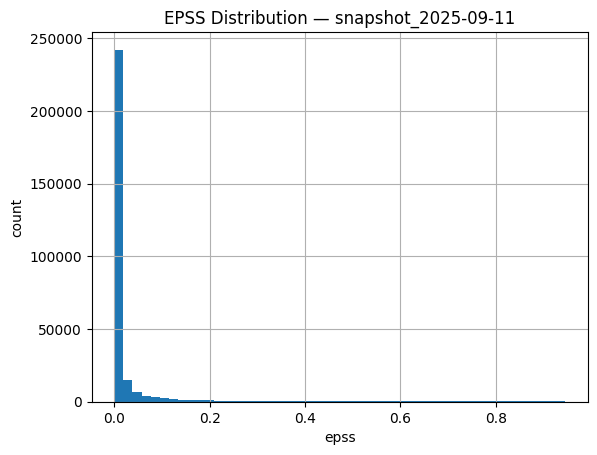

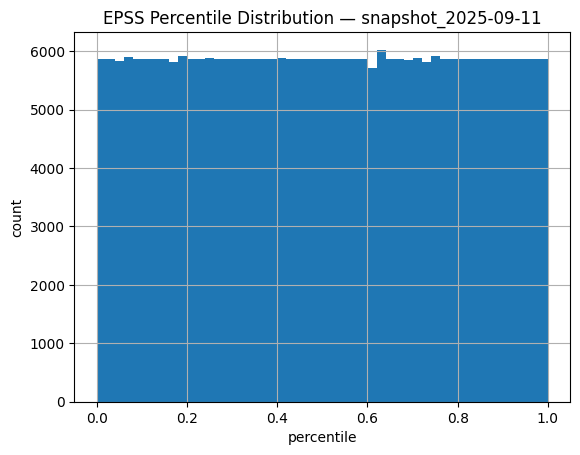

In [ ]:
# Distributions
plot_hist(df, "epss", f"EPSS Distribution — {mode_name}")
plot_hist(df, "percentile", f"EPSS Percentile Distribution — {mode_name}")

# If you fetched CVEs across multiple dates, try a simple timeseries
if RUN_MODE.upper() == "CVES":
    plot_timeseries(df, CVE_LIST)

In [ ]:
# Save DataFrame as Parquet
parquet_path = os.path.join(DATA_DIR, f"epss_{mode_name}.parquet")
df.to_parquet(parquet_path, index=False)
print("Saved:", parquet_path)

# Save plots again to files (if you want persistent PNGs)
# (Re-generate quickly without showing)
def save_hist(df, col, out_png, title):
    if df.empty or col not in df.columns:
        return
    plt.figure()
    df[col].dropna().hist(bins=50)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.savefig(out_png, bbox_inches="tight")
    plt.close()
    print("Saved chart:", out_png)

save_hist(df, "epss", os.path.join(DATA_DIR, f"hist_epss_{mode_name}.png"), f"EPSS Distribution — {mode_name}")
save_hist(df, "percentile", os.path.join(DATA_DIR, f"hist_percentile_{mode_name}.png"), f"EPSS Percentile Distribution — {mode_name}")

Saved: /content/data/epss_snapshot_2025-09-11.parquet
Saved chart: /content/data/hist_epss_snapshot_2025-09-11.png
Saved chart: /content/data/hist_percentile_snapshot_2025-09-11.png


## Additional Data Sources